In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [5]:
df.shape

(1000, 9)

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [11]:
df[["Age", "Quantity", "Price per Unit", "Total Amount"]].median()

Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [12]:
df[["Age", "Quantity", "Price per Unit", "Total Amount"]].mode().iloc[0]

Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [13]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Name: Total Amount, dtype: int64

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [16]:
!pip install matplotlib

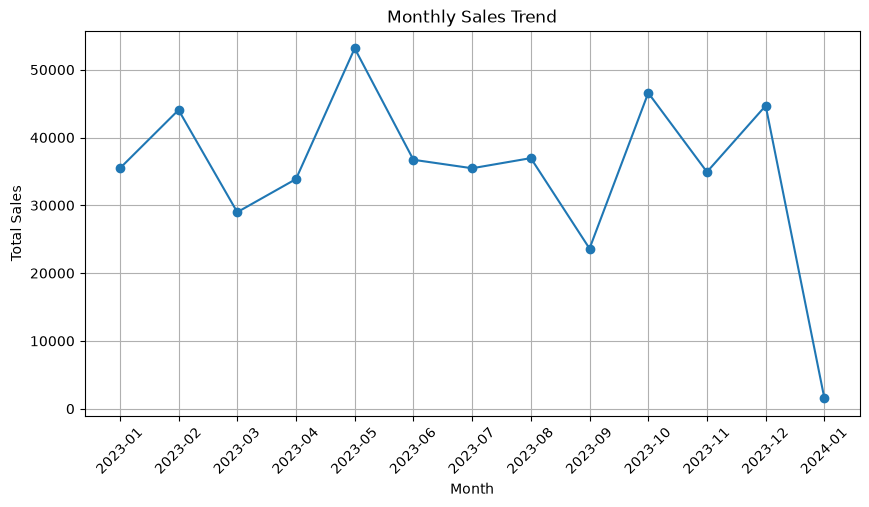

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [18]:
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()
quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Name: Total Amount, dtype: int64

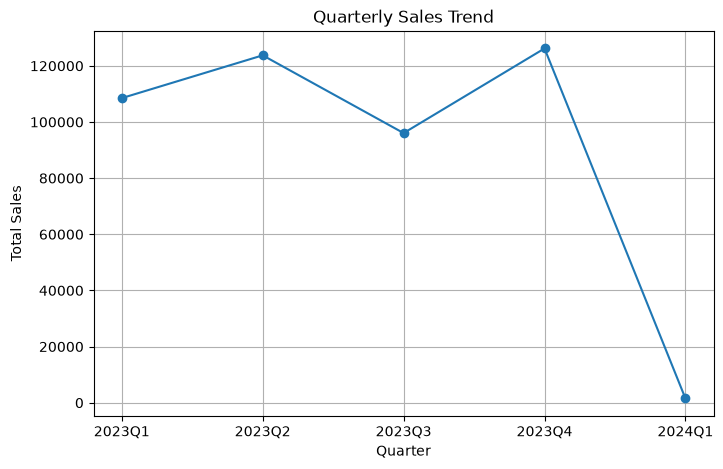

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [20]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-64"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = df["Age Group"].value_counts().sort_index()
age_group_counts

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64

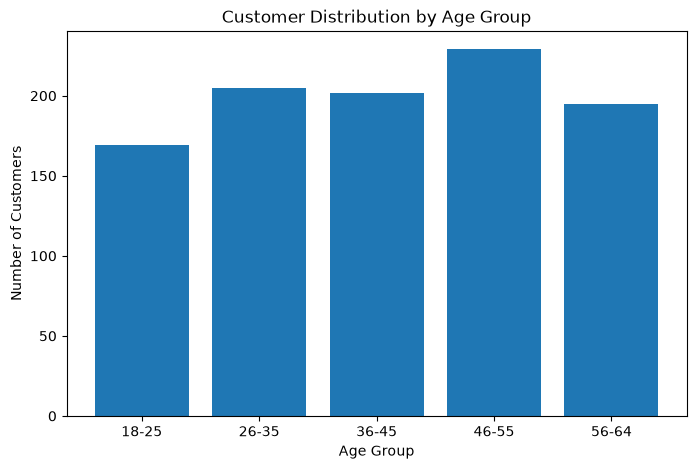

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(age_group_counts.index, age_group_counts.values)
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
gender_counts = df["Gender"].value_counts()
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

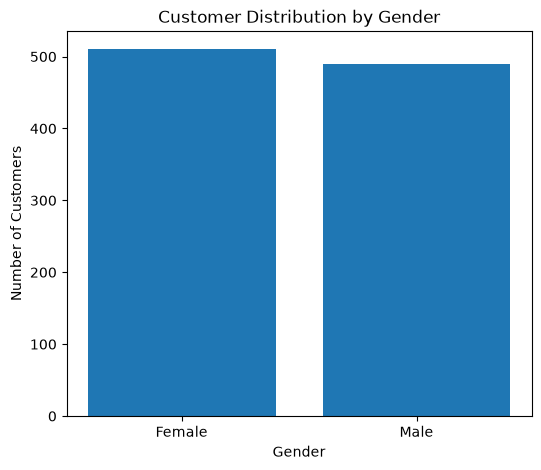

In [23]:
plt.figure(figsize=(6, 5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [24]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

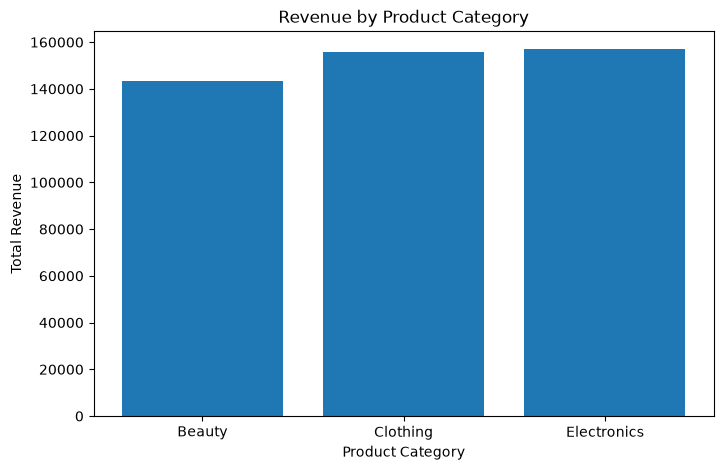

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

In [26]:
top_10_sales = df.nlargest(10, "Total Amount")[["Transaction ID", "Product Category", "Total Amount"]]
top_10_sales

,Transaction ID,Product Category,Total Amount
14,15,Electronics,2000
64,65,Electronics,2000
71,72,Electronics,2000
73,74,Beauty,2000
88,89,Electronics,2000
92,93,Beauty,2000
108,109,Electronics,2000
117,118,Electronics,2000
123,124,Clothing,2000
138,139,Beauty,2000


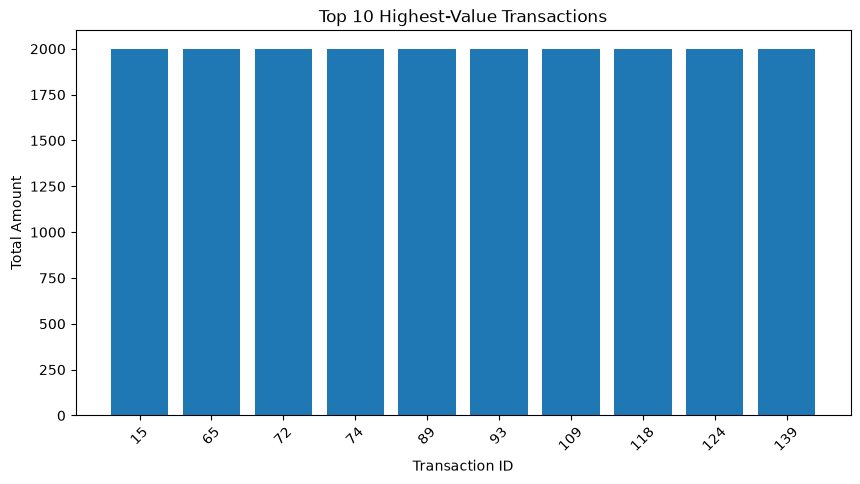

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_sales["Transaction ID"].astype(str), top_10_sales["Total Amount"])
plt.title("Top 10 Highest-Value Transactions")
plt.xlabel("Transaction ID")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

In [28]:
import seaborn as sns

numeric_data = df[["Age", "Quantity", "Price per Unit", "Total Amount"]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [29]:
!pip install seaborn

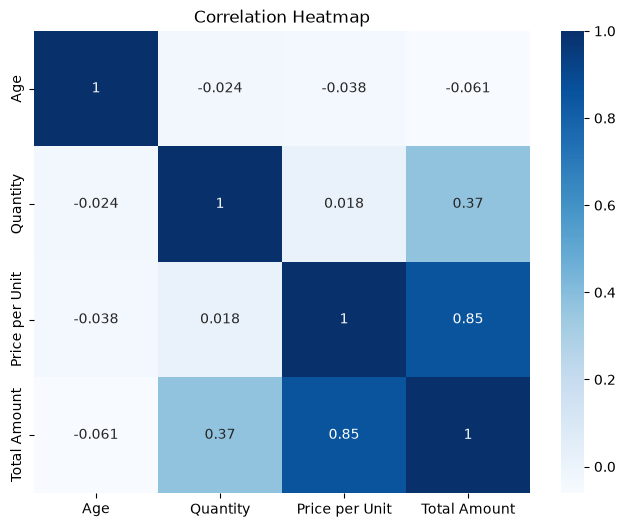

In [30]:
import seaborn as sns

numeric_data = df[["Age", "Quantity", "Price per Unit", "Total Amount"]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

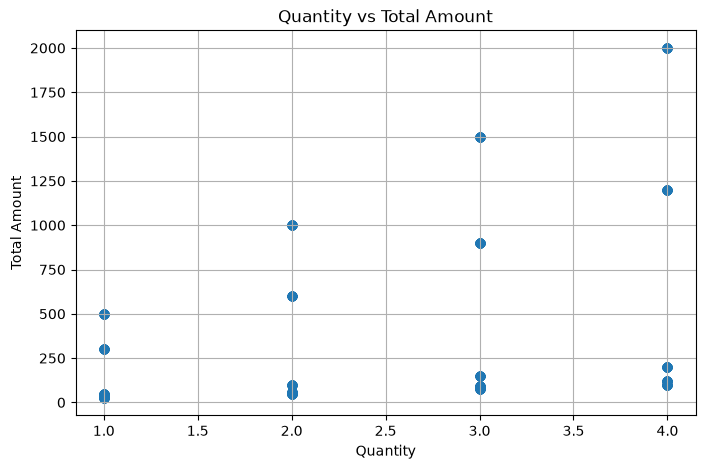

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Quantity"], df["Total Amount"])
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.grid(True)
plt.show()

### Observation
The scatter plot shows the relationship between quantity purchased and total transaction amount. Higher quantities can lead to higher transaction values, although the relationship is not perfectly linear because the price per unit also affects the total amount.

### Observation
The correlation heatmap shows how the numerical variables are related to each other. Total Amount is influenced by Quantity and Price per Unit, while Age has a weaker relationship with transaction value.

### Observation
The chart highlights the transactions with the highest total amounts. These high-value transactions contribute significantly to overall revenue and can help identify opportunities for premium product sales.

### Observation
Revenue differs across product categories, showing that some categories contribute more to overall sales than others. This can help the business focus inventory and promotions on stronger-performing categories.

### Observation
The gender breakdown shows the distribution of customers by gender. Understanding this distribution can help the business design more targeted marketing campaigns and customer offers.

### Observation
The age-group distribution shows how customers are spread across different age ranges. This information can help the business understand its main customer segments and plan suitable marketing strategies.

### Observation
The quarterly sales trend shows how total sales change across quarters. Comparing quarterly performance helps identify periods of stronger or weaker demand and supports better sales planning.

### Observation
The monthly sales trend shows fluctuations in sales throughout the year. Identifying months with higher or lower sales can help the business plan inventory, promotions, and sales activities more effectively.

## Conclusion

The retail sales analysis helped identify sales trends, customer demographics, product category performance, and relationships between numerical variables.

### Actionable Business Recommendations

1. Focus marketing and promotions on the strongest-performing product categories to increase revenue.
2. Use monthly and quarterly sales trends to plan inventory and promotional campaigns during high-demand periods.
3. Use customer age and gender distributions to create more targeted marketing offers and customer segments.